In [10]:
import os
import pydicom
from collections import defaultdict
import numpy as np
import sys
import shutil

import SimpleITK as sitk

import matplotlib.pyplot as plt
import re
from IPython.display import clear_output


Loads the dicom series, processes it to convert to nifti and saves the nifti image with managed hierarchy

In [ ]:
def load_dicom_series(dicom_folder):
    """Load a DICOM series from a folder using SimpleITK."""
    reader = sitk.ImageSeriesReader()
    dicom_filenames = reader.GetGDCMSeriesFileNames(dicom_folder)
    reader.SetFileNames(dicom_filenames)
    image = reader.Execute()
    return image

def save_as_nii_gz(sitk_image, output_path):
    image_array = sitk.GetArrayFromImage(sitk_image)
    oriented_array = np.flip(image_array, axis= 0)  # Flip the image along the Z-axis
    oriented_image = sitk.GetImageFromArray(oriented_array)
    oriented_image.CopyInformation(sitk_image)  # Copy metadata from the original image
    sitk.WriteImage(oriented_image, output_path)

def process_dicom_folder(dicom_folder, output_folder):
    """Load DICOM, process to zero left/right side, and save as .nii.gz."""
    # Load the DICOM series from the folder
    acc_image = load_dicom_series(dicom_folder)
    
    # Save the results as .nii.gz
    acc_image_path = os.path.join(output_folder, f"{os.path.basename(output_folder)}_image.nii.gz")
    
    save_as_nii_gz(acc_image, acc_image_path)

    print(f"Saved: {acc_image_path}")


Calling function to preoess the series of dicom files and save as nifti

In [ ]:
root_dir = "/media/interns/storage/PLAI/assign_data/processed_validation_june"
save_path = "/media/interns/storage/PLAI/assign_data/validation_june_finalized"

for patient in os.listdir(root_dir):
    patient_dir = os.path.join(root_dir, patient)
    for subdirs in os.listdir(patient_dir):
        subdir_path = os.path.join(patient_dir, subdirs)
        if "stl_files" in subdir_path:
            continue
        for series in os.listdir(subdir_path):
            series_path = os.path.join(subdir_path, series)
            series_save_path = os.path.join(save_path, patient, subdirs, series)
            os.makedirs(series_save_path, exist_ok=True)
            process_dicom_folder(series_path, series_save_path)
    print(f"Processed patient: {patient}")
    print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
    print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")

Visualizes the nifti images for middle slice

Input parameter: Nifti image path

In [11]:
def visualize_nifti_middle_slices_sitk(image_path):
    image = sitk.ReadImage(image_path)
    print(f"Image Size: {image.GetSize()}")
    image_array = sitk.GetArrayFromImage(image)  # [z, y, x]

    z, y, x = image_array.shape

    # Extract sagittal slices (X-axis)
    start_middle_sagittal = image_array[:, :, 2 * (x // 2) // 3]
    middle_sagittal = image_array[:, :, x // 2]
    end_middle_sagittal = image_array[:, :, 3 * (x // 2) // 2]

    # Extract coronal slices (Y-axis)
    start_middle_coronal = image_array[:, 2 * (y // 2) // 3, :]
    middle_coronal = image_array[:, y // 2, :]
    end_middle_coronal = image_array[:, 3 * (y // 2) // 2, :]

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))

    titles = [
        'Start-Middle Sagittal', 'Middle Sagittal', 'End-Middle Sagittal',
        'Start-Middle Coronal', 'Middle Coronal', 'End-Middle Coronal'
    ]
    
    sagittal_slices = [start_middle_sagittal, middle_sagittal, end_middle_sagittal]
    coronal_slices = [start_middle_coronal, middle_coronal, end_middle_coronal]

    # Axis ticks
    z_ticks = np.arange(0, z, 50)
    x_ticks = np.arange(0, x, 50)
    y_ticks = np.arange(0, y, 50)

    # Plot sagittal slices
    for i, slice_img in enumerate(sagittal_slices):
        axes[0, i].imshow(slice_img, cmap='gray', origin='upper', aspect='auto')
        axes[0, i].set_title(titles[i])
        axes[0, i].set_ylabel('Z-axis (Height)')
        axes[0, i].set_xlabel('Y-axis')
        axes[0, i].set_yticks(z_ticks)
        axes[0, i].set_xticks(y_ticks)

    # Plot coronal slices
    for i, slice_img in enumerate(coronal_slices):
        axes[1, i].imshow(slice_img, cmap='gray', origin='upper', aspect='auto')
        axes[1, i].set_title(titles[i + 3])
        axes[1, i].set_ylabel('Z-axis (Height)')
        axes[1, i].set_xlabel('X-axis')
        axes[1, i].set_yticks(z_ticks)
        axes[1, i].set_xticks(x_ticks)

    plt.tight_layout()
    plt.show()


Splits the image vertically for bilateral legs


In [ ]:
def inclined_split_axial_nifti(image, output_dir, region, upper_percent=50, lower_percent=50):
    """
    Splits a NIfTI image along the axial x-axis with an inclined line defined by upper_percent (top row) and lower_percent (bottom row).
    
    Parameters:
    - image: loaded nifti image
    - output_dir: Directory to save outputs
    - region: Region name, to manage hierarchy on save path
    - upper_percent: Split percentage at top of image (0–100)
    - lower_percent: Split percentage at bottom of image (0–100)
    """
    assert 0 <= upper_percent <= 100 and 0 <= lower_percent <= 100, "Percent values must be between 0 and 100"

    # Load image and convert to numpy
    # image = sitk.ReadImage(nifti_path)
    array = sitk.GetArrayFromImage(image)  # (z, y, x)
    z, y, x = array.shape

    # Compute split column per row (y)
    x_coords = np.linspace(upper_percent / 100 * x, lower_percent / 100 * x, y).astype(int)  # shape: (y,)

    # Create masks
    left_array = np.zeros_like(array)
    right_array = np.zeros_like(array)

    for z_idx in range(z):
        for y_idx in range(y):
            split_col = x_coords[y_idx]
            left_array[z_idx, y_idx, :split_col] = array[z_idx, y_idx, :split_col]
            right_array[z_idx, y_idx, split_col:] = array[z_idx, y_idx, split_col:]

    # Convert to images and preserve metadata
    left_image = sitk.GetImageFromArray(left_array)
    right_image = sitk.GetImageFromArray(right_array)
    left_image.CopyInformation(image)
    right_image.CopyInformation(image)

    left_region = os.path.join(output_dir, f"left_{region}")
    right_region = os.path.join(output_dir, f"right_{region}")
    os.makedirs(left_region, exist_ok=True)
    os.makedirs(right_region, exist_ok=True)

    left_path = os.path.join(left_region, f"{region}_image.nii.gz")
    right_path = os.path.join(right_region, f"{region}_image.nii.gz")

    # Save
    sitk.WriteImage(left_image, left_path)
    sitk.WriteImage(right_image, right_path)

    print(f"Saved inclined split images:\n  {left_path}\n  {right_path}")

Starting from 0 to (N)th z slice to take the slices for particular region

eg: if an image contains both knee and ankle then consider slice 0-340 is knee and slice 340-510 is ankle

if split valie is 0, 0 then it considers image as unilateral image and processes the image accordingly

In [ ]:
def extract_axial_slice_range(nifti_path, output_dir, region, start_slice, end_slice):
    """
    Extracts and saves axial slices from start_slice to end_slice (inclusive) into a new NIfTI file.

    Parameters:
    - nifti_path: Path to the input NIfTI image.
    - output_dir: Directory to save the extracted image.
    - region: Region name, to manage hierarchy on save path
    - start_slice: Starting Z-index (inclusive).
    - end_slice: Ending Z-index (inclusive).
    """
    image = sitk.ReadImage(nifti_path)
    array = sitk.GetArrayFromImage(image)  # Shape: (z, y, x)
    z = array.shape[0]

    # Validate slice range
    assert 0 <= start_slice <= end_slice < z, f"Slice indices must be within [0, {z-1}]"

    # Extract subvolume
    extracted_array = array[start_slice:end_slice + 1]

    # Convert back to SimpleITK image
    extracted_image = sitk.GetImageFromArray(extracted_array)
    
    # Adjust origin to reflect new slice position
    original_origin = list(image.GetOrigin())
    spacing = image.GetSpacing()
    new_origin = original_origin
    new_origin[2] += start_slice * spacing[2]
    extracted_image.SetOrigin(tuple(new_origin))
    
    extracted_image.SetSpacing(image.GetSpacing())
    extracted_image.SetDirection(image.GetDirection())

    input_str = input("Enter upper and lower percentage from the approximation for the visualization given below: ")
    upper_percent, lower_percent = map(int, input_str.split(','))

    if upper_percent ==0 and lower_percent == 0:
        images = "unilateral"
        os.makedirs(output_dir, exist_ok=True)
        output_path = os.path.join(output_dir, f"{region}_image.nii.gz")
        sitk.WriteImage(extracted_image, output_path)
    else:
        inclined_split_axial_nifti(extracted_image, output_dir, region, upper_percent, lower_percent)

    # print(f"Extracted axial slices {start_slice} to {end_slice} and saved to:\n  {output_path}")



First of all, it visualizes the nifti image within cell

it asks user for input for start and end slice index to take specific slices in image | 
example input: 0, 245

again it asks for region name | 
example input: ankle

if input is given like ankle, re it starts over again (In case server runs slow and fails to visualize)

Image Size: (512, 512, 865)


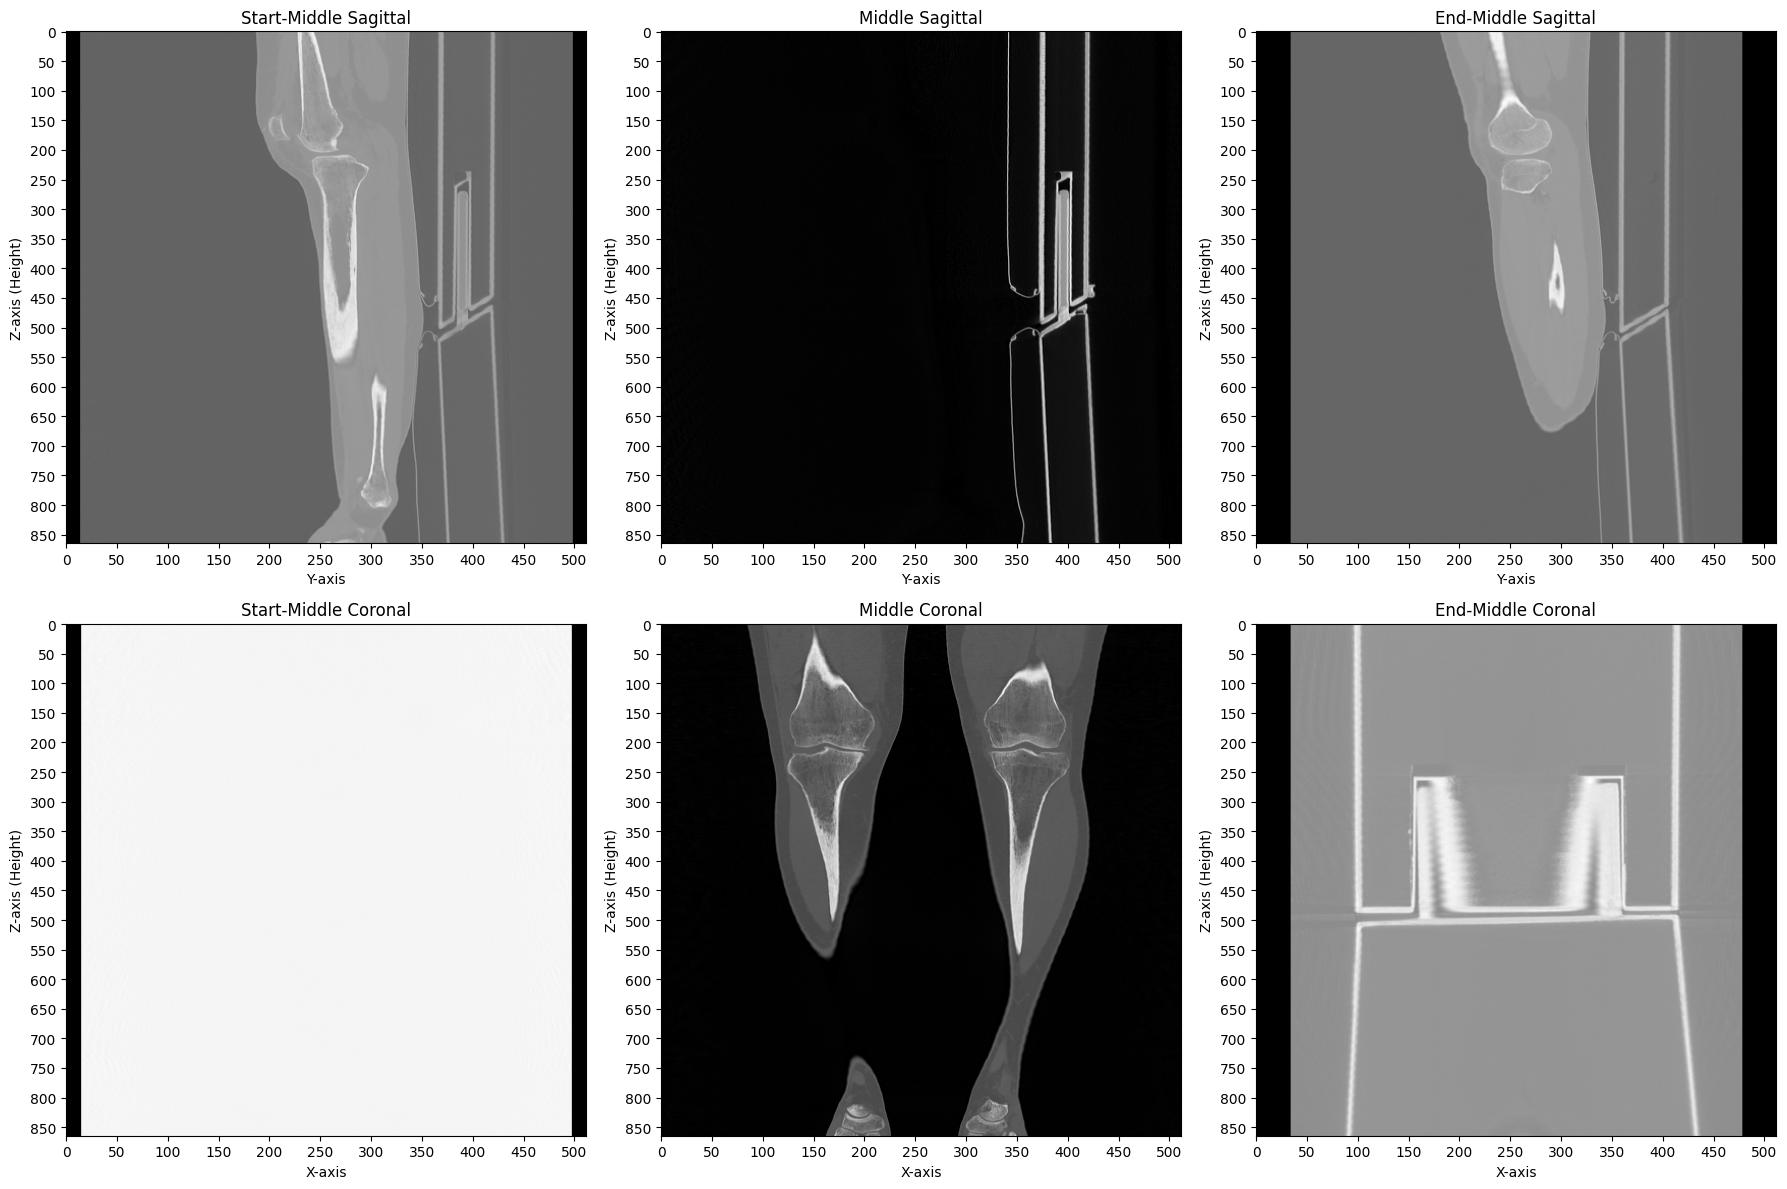

KeyboardInterrupt: Interrupted by user

In [36]:
root_dir = "/media/interns/storage/PLAI/assign_data/validation_june_finalized"
save_path = "/media/interns/storage/PLAI/assign_data/june_images"

# for patient in os.listdir(root_dir):
#     patient_dir = os.path.join(root_dir, patient)
patient_dir = "/media/interns/storage/PLAI/assign_data/validation_june_finalized/Romania (12)"

patient = os.path.basename(patient_dir)

for subdirs in os.listdir(patient_dir):
    subdir_path = os.path.join(patient_dir, subdirs)

    for series in os.listdir(subdir_path):
        series_path = "/media/interns/storage/PLAI/assign_data/validation_june_finalized/Romania (12)/DICOM/HIP_KNEE_ANKLE_2"
        series = "HIP_KNEE_ANKLE_2"
        series_save_path = os.path.join(save_path, patient, subdirs, series)
        os.makedirs(series_save_path, exist_ok=True)
        for file in os.listdir(series_path):
            nifti_image_path = os.path.join(series_path, file)
            repeat = "re"
            while repeat == "re":
                visualize_nifti_middle_slices_sitk(nifti_image_path)
                input_str = input("Enter start and end slice indices from the approximation for the visualization given below: ")
                start_slice, end_slice = map(int, input_str.split(','))
                user_input = input("Enter anatomy (pelvis, knee, ankle) you are processing from the visualization given below: ")
                if ',' in user_input:
                    region, repeat = user_input.split(',', 1)
                    region = region.strip()
                    repeat = repeat.strip()
                else:
                    region = user_input.strip()
                    repeat = "no"
                extract_axial_slice_range(nifti_image_path, series_save_path, region, start_slice, end_slice-1)
                clear_output(wait=True)
    print(f"Processed patient: {patient}")
    print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
    print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
